In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torchinfo
import torchvision.transforms.functional as VF
from torch import nn
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from tqdm import tqdm
from torchlake.common.utils.image import ycbcr_transform, ycbcr_inverse_transform

from torchlake.common.controller.evaluator import RegressionEvaluator
from torchlake.common.controller.weight_manager import WeightManager
from torchlake.common.datasets.images import ImageDataset
from torchlake.common.utils.convert import img_tensor_to_np
from torchlake.common.utils.plot import plot_grids
from torchlake.super_resolution.controller.trainer_srcnn import SRCNNTrainer
from torchlake.super_resolution.models.srcnn import SRCNN

# Setting

In [2]:
PATCH_SIZE = 33
# PADDING = (33-21)//2
STRIDE = 14
# IMAGE_SIZE = 336
BATCH_SIZE = 128 # full image => 16 worse

In [3]:
DEVICE = torch.device("cuda:0")

In [4]:
artifact_path = Path("../../artifacts/srcnn")
artifact_path.mkdir(exist_ok=True)

data_path = Path("../../data/srcnn/Train/*.bmp")
# data_path = Path("../../data/VOCdevkit/VOC2012/JPEGImages/*")
degrade_patch_path = Path("../../data/srcnn/x")
degrade_patch_path.mkdir(exist_ok=True)
clear_patch_path = Path("../../data/srcnn/y")
clear_patch_path.mkdir(exist_ok=True)
patch_path = Path("../../data/srcnn")

# Data

In [5]:
SCALE_FACTOR = 2

In [6]:
preprocess = v2.Compose(
    [
        v2.ToImage(),
        # v2.Resize((IMAGE_SIZE, IMAGE_SIZE)), # 336, 512 same psnr
        v2.ToDtype(torch.float32, scale=True),
    ]
)

In [7]:
train_dataset = ImageDataset(
    data_path.as_posix(),
    transform=preprocess,
    # debug_size=300, # 300, 500 same psnr
)

In [8]:
print(train_dataset[0].shape)

torch.Size([3, 176, 197])


In [9]:
patch_extractor = nn.Unfold(PATCH_SIZE, stride=STRIDE)

def collate_fn(batch):
    xs, ys = [], []
    for x in batch:
        x = x.unsqueeze(0)
        
        if x.size(1) == 1:
            x = x.repeat(1, 3, 1, 1)
        
        # rgb -> ycbcr
        x = ycbcr_transform(x)
            
        x = x[:, 0:1, :, :]

        # mod crop
        h, w = x.shape[-2:]
        x = VF.crop(x, 0, 0, h - h % SCALE_FACTOR, w - w % SCALE_FACTOR)
        h, w = x.shape[-2:]

        # degradation
        y = F.interpolate(x, size=(h // SCALE_FACTOR, w // SCALE_FACTOR), mode="bicubic")
        y = F.interpolate(y, size=(h, w), mode="bicubic")
        
        # patch
        x = patch_extractor(x).permute(0, 2, 1).reshape(-1, 1, PATCH_SIZE, PATCH_SIZE)
        y = patch_extractor(y).permute(0, 2, 1).reshape(-1, 1, PATCH_SIZE, PATCH_SIZE)
        
        xs.append(y) # .clamp(0, 1) worse model, enhance bicubic
        ys.append(x)
        
    xs, ys = torch.cat(xs), torch.cat(ys)
    
    # random patch in a batch => same psnr
    # random_indices = torch.randperm(len(xs))
    # xs = xs[random_indices]
    # ys = ys[random_indices]

    return xs, ys

In [ ]:
# uncomment to create patches

# import cv2
# import numpy as np

# patch_loader = DataLoader(
#     train_dataset,
#     batch_size=BATCH_SIZE,
#     collate_fn=collate_fn,
#     shuffle=False,
#     drop_last=False,
# )

# i = 0
# for x, y in tqdm(patch_loader):
#     for patch_x, patch_y in zip(img_tensor_to_np(x, scale=255, output_type=np.uint8), img_tensor_to_np(y, scale=255, output_type=np.uint8)):
#         cv2.imwrite(degrade_patch_path / f"{i}.jpg", patch_x)
#         cv2.imwrite(clear_patch_path / f"{i}.jpg", patch_y)
#         i+=1

In [11]:
from torchlake.common.utils.image import load_image

class SRCNNDataset(torch.utils.data.Dataset):
    def __init__(self, root: str | Path, transform=None):
        self.root = Path(root)
        self.paths = tuple(self.root.glob("x/*.jpg"))
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        x = load_image(self.paths[idx], is_tensor=True)
        y = load_image(self.paths[idx].as_posix().replace("x", "y"), is_tensor=True)
        
        if self.transform:
            x = self.transform(x)

        return x, y

In [12]:
train_dataset = SRCNNDataset(patch_path)

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    # collate_fn=collate_fn,
    pin_memory=True,
    drop_last=True,
)

In [14]:
for x, y in train_loader:
    print(x.shape, y.shape)
    break

torch.Size([128, 1, 33, 33]) torch.Size([128, 1, 33, 33])


# model

In [15]:
model = SRCNN(
    input_channel=1,
    kernels=(9, 5, 5),
    hidden_dims=(64, 32),
).to(DEVICE)

In [16]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
SRCNN                                    --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  5,248
│    │    └─ReLU: 3-2                    --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-3                  51,232
│    │    └─ReLU: 3-4                    --
├─Sequential: 1-2                        --
│    └─Conv2d: 2-3                       801
Total params: 57,281
Trainable params: 57,281
Non-trainable params: 0

# train

In [17]:
EPOCHS = 30

In [18]:
trainer = SRCNNTrainer(EPOCHS, DEVICE)
trainer.recorder.increment_data_size(len(train_dataset))

In [19]:
criterion = trainer.get_criterion('l2')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # lr=1e-3, 1e-4 same psnr

In [20]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, threshold=.05 ,threshold_mode ='rel')

In [21]:
scaler = torch.amp.GradScaler(DEVICE)

In [22]:
training_loss = trainer.run(
    train_loader,
    model,
    optimizer,
    criterion,
    scheduler=scheduler,
    scaler=scaler,
)

Enable AMP: True
Training...


100%|██████████| 171/171 [00:24<00:00,  6.95it/s]


------------------------------------
Epoch 1
------------------------------------
total: 1.2072e-04 (0.00%)


100%|██████████| 171/171 [00:24<00:00,  7.10it/s]


------------------------------------
Epoch 2
------------------------------------
total: 3.7634e-05 (-69.00%)


...

------------------------------------
Epoch 28
------------------------------------
total: 1.5725e-05 (-1.00%)


100%|██████████| 171/171 [00:21<00:00,  7.94it/s]


------------------------------------
Epoch 29
------------------------------------
total: 1.5834e-05 (1.00%)


100%|██████████| 171/171 [00:23<00:00,  7.41it/s]

------------------------------------
Epoch 30
------------------------------------
total: 1.4774e-05 (-7.00%)


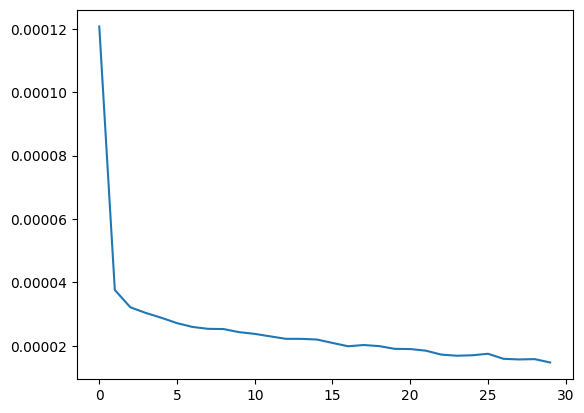

In [23]:
plt.plot(training_loss)

In [24]:
manager = WeightManager(artifact_path.joinpath("srcnn.pth").as_posix())

In [25]:
model_path = manager.get_filename()
model_path

WindowsPath('../../artifacts/srcnn/srcnn.pth')

In [26]:
manager.save_weight(model.state_dict(), model_path)

Save weight to ..\..\artifacts\srcnn\srcnn.pth, model size is 0.22MiB


In [27]:
manager.load_weight(model_path, model)

# Eval

In [28]:
# test_data_path = Path("../../data/VOCdevkit/VOC2012/JPEGImages/*")
test_data_path = Path("../../data/srcnn/Test/Set14/*.bmp")

In [29]:
test_preprocess = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

In [30]:
test_dataset = ImageDataset(
    test_data_path.as_posix(),
    transform=test_preprocess,
)

In [31]:
print(test_dataset[0].shape)

torch.Size([3, 480, 500])


In [32]:
def val_collate_fn(batch):
    xs, ys = [], []
    for x in batch:
        x = x.unsqueeze(0)
        
        if x.size(1) == 1:
            x = x.repeat(1, 3, 1, 1)
        
        # rgb -> ycbcr
        x = ycbcr_transform(x)
        
        x = x[:, 0:1]
        
        # mod crop
        h, w = x.shape[-2:]
        x = VF.crop(x, 0, 0, h - h % SCALE_FACTOR, w - w % SCALE_FACTOR)
        h, w = x.shape[-2:]
        
        # degradation
        y = F.interpolate(x, size=(h // SCALE_FACTOR, w // SCALE_FACTOR), mode="bicubic")
        y = F.interpolate(y, size=(h, w), mode="bicubic")
        
        xs.append(y)
        ys.append(x)

    return torch.cat(xs), torch.cat(ys)

In [33]:
val_loader = DataLoader(
    test_dataset,
    batch_size=1,
    collate_fn=val_collate_fn,
    pin_memory=True,
)

In [34]:
for x, y in tqdm(val_loader):
    print(x.shape, y.shape)
    break
    # pass

  0%|          | 0/14 [00:00<?, ?it/s]

torch.Size([1, 1, 480, 500]) torch.Size([1, 1, 480, 500])


In [35]:
# from typing import Any, Iterable


class SRCNNEvaluator(RegressionEvaluator):
#     def _predict(
#         self,
#         row: tuple[Iterable],
#         model: nn.Module,
#         *args,
#         **kwargs,
#     ) -> torch.Tensor | Any:
#         x, _ = row
#         x: torch.Tensor = x.to(self.device)
#         output = model(x[:, 0:1, :, :], *args, **kwargs)
#         # for output that has feature in last
#         if self.feature_last:
#             output = output.permute(0, -1, *range(1, len(output.shape) - 1))
            
#         output = torch.cat((output, x[:, 1:3]), 1)
#         return output
    
    def _update_metric(self, metric, y: torch.Tensor, yhat: torch.Tensor):
        metric.update(
            yhat.detach().cpu().mul(255).int()[:, :, SCALE_FACTOR:-SCALE_FACTOR, SCALE_FACTOR:-SCALE_FACTOR], 
            y.mul(255).int()[:, :, SCALE_FACTOR:-SCALE_FACTOR, SCALE_FACTOR:-SCALE_FACTOR],
        )

## PSNR

In [36]:
from torchmetrics.image import PeakSignalNoiseRatio

In [37]:
metric = PeakSignalNoiseRatio(data_range=255)

In [38]:
evaluator = SRCNNEvaluator(DEVICE)

In [39]:
metric = evaluator.run(val_loader, model, metric)

  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 50.18it/s]


In [40]:
metric.compute()

tensor(27.5380)

In [41]:
metric = PeakSignalNoiseRatio(data_range=255)

In [42]:
evaluator = SRCNNEvaluator(DEVICE)

In [43]:
metric = evaluator.run(val_loader, nn.Identity(), metric)

100%|██████████| 14/14 [00:00<00:00, 83.83it/s]


In [44]:
metric.compute()

tensor(28.0208)

## Inference

In [45]:
def test_collate_fn(batch):
    xs, ys = [], []
    for x in batch:
        x = x.unsqueeze(0)
        
        if x.size(1) == 1:
            x = x.repeat(1, 3, 1, 1)
        
        # rgb -> ycbcr
        x = ycbcr_transform(x)
        
        # mod crop
        h, w = x.shape[-2:]
        x = VF.crop(x, 0, 0, h - h % SCALE_FACTOR, w - w % SCALE_FACTOR)
        h, w = x.shape[-2:]
        
        # degradation
        # y = F.interpolate(x, size=(h // SCALE_FACTOR, w // SCALE_FACTOR), mode="bicubic")
        # y = F.interpolate(y, size=(h, w), mode="bicubic")
        y = F.interpolate(x[:, 0:1], size=(h // SCALE_FACTOR, w // SCALE_FACTOR), mode="bicubic")
        y = F.interpolate(y, size=(h, w), mode="bicubic")
        y = torch.cat((y, x[:, 1:3]), 1)
        
        xs.append(y)
        ys.append(x)

    return torch.cat(xs), torch.cat(ys)

In [46]:
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    collate_fn=test_collate_fn,
    pin_memory=True,
)

In [47]:
for x, y in tqdm(test_loader):
    print(x.shape, y.shape)
    break
    # pass

  0%|          | 0/14 [00:00<?, ?it/s]

torch.Size([1, 3, 480, 500]) torch.Size([1, 3, 480, 500])


In [48]:
model.eval()
with torch.inference_mode(True):
    # output = model(x.to(DEVICE))
    # output = output.detach().cpu()
    
    output = model(x[:, 0:1].to(DEVICE))
    output = output.detach().cpu()
    output = torch.cat((output, x[:, 1:3, :, :]), 1)

In [49]:
x.shape, output.shape

(torch.Size([1, 3, 480, 500]), torch.Size([1, 3, 480, 500]))

In [50]:
# claude code suggests identity check
(output - x).abs().mean(), (output - y).abs().mean(), (y - x).abs().mean()

(tensor(0.0037), tensor(0.0161), tensor(0.0158))

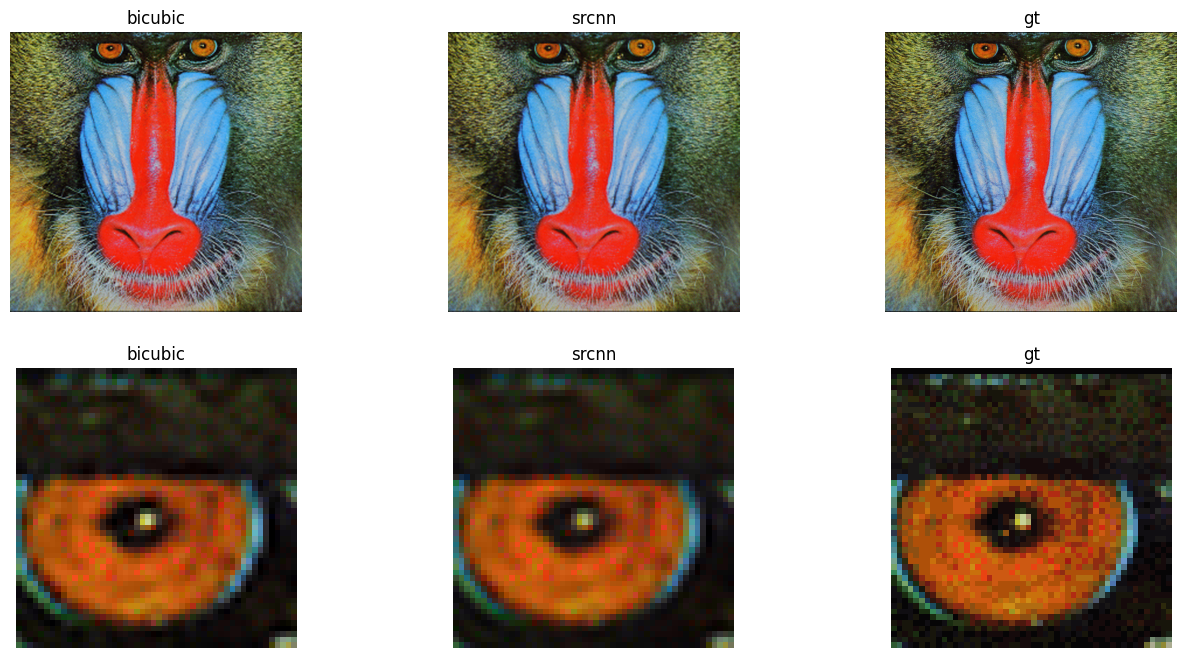

In [61]:
bicubic_img = img_tensor_to_np(ycbcr_inverse_transform(x).clamp(0, 1))
srcnn_img = img_tensor_to_np(ycbcr_inverse_transform(output).clamp(0, 1))
gt = img_tensor_to_np(ycbcr_inverse_transform(y).clamp(0, 1))

bicubic_patch = bicubic_img[0:50, 150:200]
srcnn_patch = srcnn_img[0:50, 150:200]
gt_patch = gt[0:50, 150:200]

plot_grids(
    (bicubic_img, srcnn_img, gt, bicubic_patch, srcnn_patch, gt_patch),
    ("bicubic", "srcnn", "gt") * 2,
    num_col=3,
    num_row=2,
    figsize=(16, 8)
)

In [52]:
# plot_grids(img_tensor_to_np(model.foot[0][0].weight[:, 0:1].detach().cpu()), num_col=8, num_row=8)

In [53]:
# plot_grids(img_tensor_to_np(model.foot[1][0].weight[:, 0:1].detach().cpu()), num_col=8, num_row=4)

In [54]:
# plot_grids(img_tensor_to_np(model.head[0].weight[0:1, :].transpose(0, 1).detach().cpu()), num_col=8, num_row=4)